# Le pipeline pas à pas et en images

Nous présentons ici un exemple simple et complet reposant sur une collection de traces simulées à partir d’un réseau. Le réseau est un extrait de la BDTOPO situé sur un versant de montagne en face de la ville de Chamonix, il représente un cas non complexe de tronçons.

Ce pipeline est exécuté en une seule itération.



## Import des librairies

- Les deux librairies socles : tracklib et footprint2graph 
- Pour visualiser les résultats : matplotlib

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Import tracklib
import tracklib as tkl

# Import footprint2graph
import footprint2graph


## Import des données : réseau puis traces simulées

Number of edges= 7
Number of nodes= 8



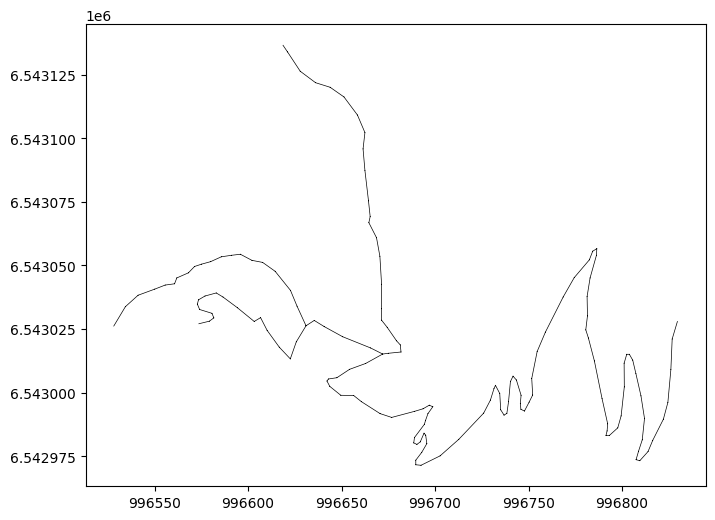

In [2]:
# WKT;link_id;source;target;direction;wkt_source;wkt_target
fmt = tkl.NetworkFormat({
       "pos_edge_id": 1,
       "pos_source": 2,
       "pos_target": 3,
       "pos_wkt": 0,
       "srid": "ENU",
       "separator": ";",
       "header": 1})
netpath = os.path.abspath(os.path.join('../../../data/network_quickstart.csv'))
network = tkl.NetworkReader.readFromFile(netpath, fmt, verbose=False)

plt.figure(figsize=(8, 6))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)

print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
print ('')

100% (1000 of 1000) |####################| Elapsed Time: 0:00:09 Time:  0:00:090000


------------------------------------------------------------
877 (87.7 %) tracks generated on network
------------------------------------------------------------


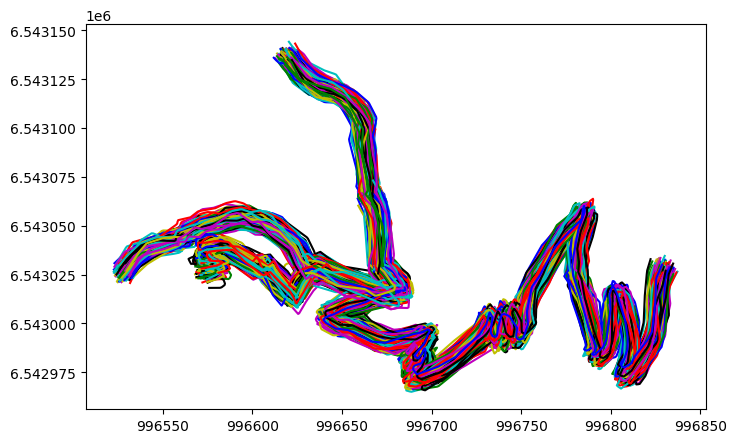

In [3]:
tkl.stochastics.seed(333)
#
noiser = tkl.NoiseProcess(amps=2.5, kernels=tkl.ExponentialKernel(80))

# generate simulated trajectories from the network 
collection = tkl.generateTracksOnNetwork(network, N=1000, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

# add 3 attributes
for idx, track in enumerate(collection):
    track.createAnalyticalFeature('TID', idx+1)

#
plt.figure(figsize=(8, 5))
collection.plot(append=plt)

## Dossier de stockage des résultats

In [4]:
from footprint2graph import prepareEnv, setupEnv, logEnv

RESPATH = r'/home/md_vandamme/7_LIB/footprint2graph/test/resultjn/'

import os
import shutil

# Suppression des répertoires
prepareEnv(RESPATH)

# Création des répertoires
iteration_index = 1
setupEnv(RESPATH, iteration_index)

# Log environment information
logEnv(RESPATH)

#  On définit un format pour le stockage des traces modifiées dans le pipeline
fmt = tkl.TrackFormat({'ext': 'CSV',
                       'srid': 'ENU',
                       'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                       'time_fmt': '2D/2M/4Y 2h:2m:2s',
                       'separator': ';',
                       'header': 0,
                       'cmt': '#',
                       'read_all': True})

pipeline_idx = 1

## Step 1 : segmentation and resampling

In [5]:
from footprint2graph import segmentation_resample

# Paramètre : Nombre de points minimum pour un morceau de trace au moment du découpage
#             si le nombre n'est pas atteint, le morceau de trace est oublié
NB_OBS_MIN           = 10

# Paramètre : Distance en mètres entre 2 points, si supérieure au seuil on coupe la trace
DIST_MAX_2OBS        = 50


RESAMPLE_SIZE_GRID = 1
RESAMPLE_SIZE_FUSION = 5

# =============================================================================
#  On définit un format pour le stockage des traces modifiées dans le pipeline

segmentation_resample(RESPATH, collection, fmt, NB_OBS_MIN, DIST_MAX_2OBS,
                    RESAMPLE_SIZE_GRID, RESAMPLE_SIZE_FUSION)





Starting segmentation and resampling...
Starting segmentation ...
    Number of tracks to resample:  877
Stage 1 finished: segmentation and resampling.


In [6]:
from footprint2graph import report_file

report_file(RESPATH, 'rawdata.json')

                  PIPELINE REPORT INFORMATION                    

Informations sur les données en entrée 
    Fin du traitement : 04/07/2026 23:24:06

--------------------------------------------------
Number of tracks :                      877
Number of traces split :                0
Number of traces after preprocessing :  877

Moyenne des distances :                 309 m
Moyenne du nombre de points :           313

--------------------------------------------------
Emprise spatiale
  XMin = 996522.591, YMin = 6542965.065, XMax = 996837.174, YMax = 6543144.124



## Step 2 : calculs des cartes de densités, de constraste et binaire

In [7]:
from footprint2graph import density_polygonize

# Définition des grilles géométrique et contraste
G1_SIZE              = 2
G2_SIZE              = 30

SEUIL_DENSITE = 25    # pas d'unité 
SEUIL_SURFACE = 1000  # m2

density_polygonize(RESPATH, G1_SIZE, G2_SIZE, SEUIL_DENSITE, SEUIL_SURFACE, pipeline_idx)


Starting rasterization and vectorization (iteration 1) 



100% (291 of 291) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (287 of 287) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1417 of 1417) |####################| Elapsed Time: 0:00:00 Time:  0:00:00


Stage 2 completed: rasterization and vectorization.


Warning 1: /home/md_vandamme/7_LIB/footprint2graph/test/resultjn/image/road_surface_lissee_1.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.


Text(0.5, 1.0, 'Road surface lissée')

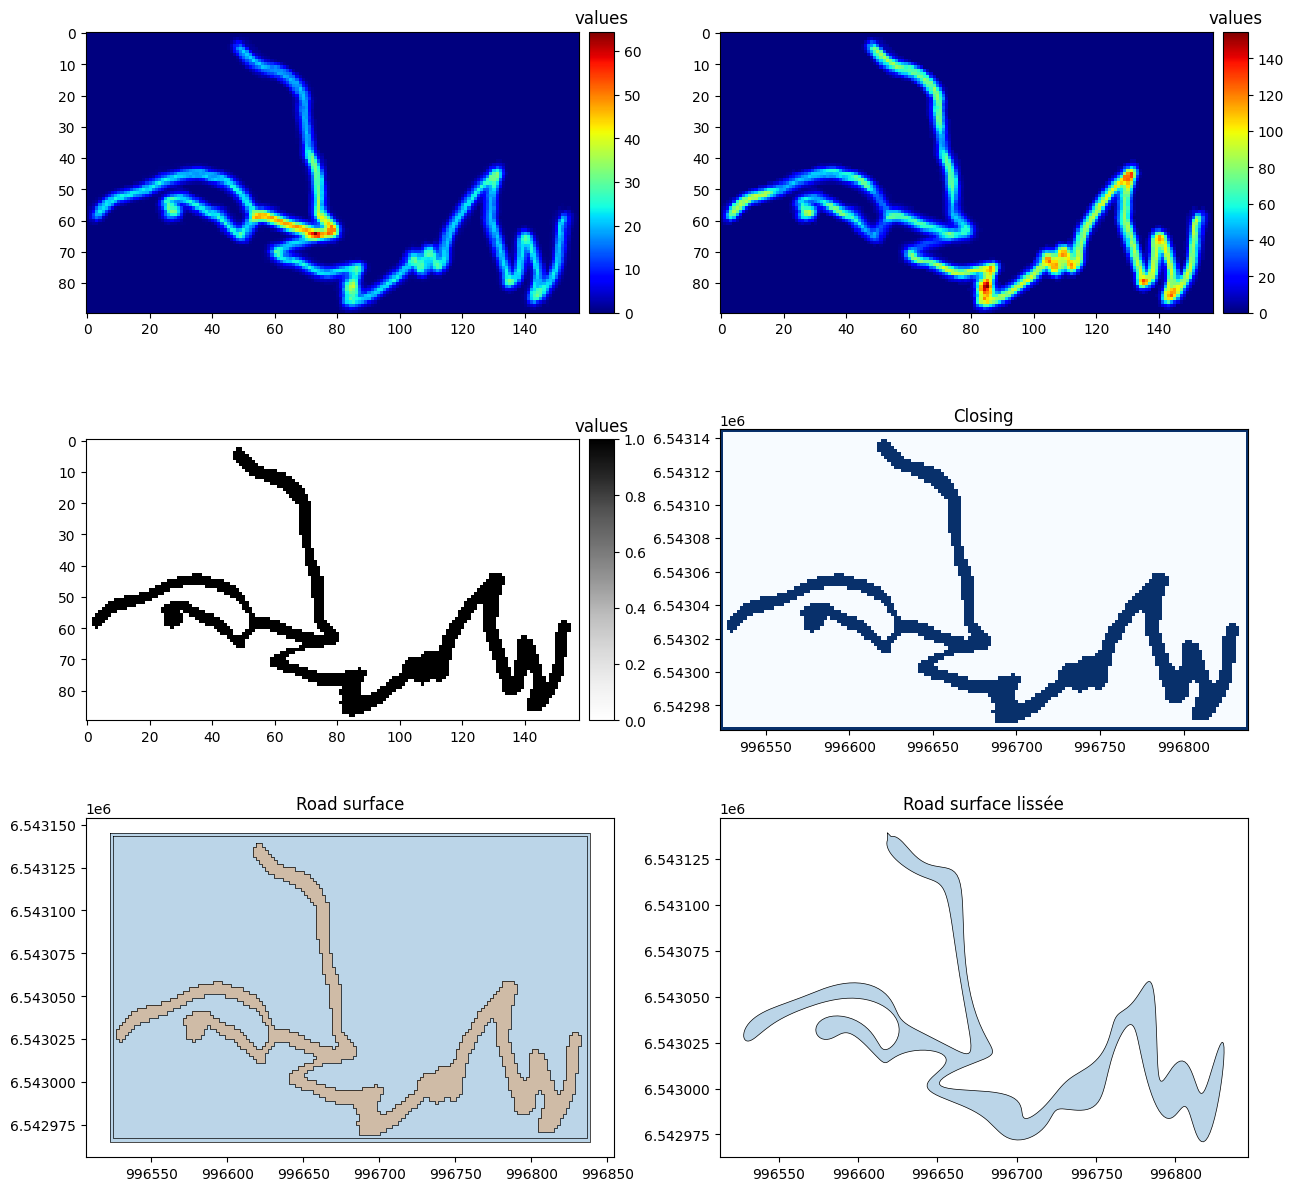

In [8]:
from footprint2graph.util.PlotRes import matPlotShapefile, maPlotRasterTiff


plt.figure(figsize=(15, 15))

# ----------------------------------------------------------------------------------------------------------
ax1 = plt.subplot2grid((3, 2), (0, 0))
rasterG1 = tkl.RasterReader.readFromAscFile(RESPATH + 'image/G1_1.asc', af_name='G1', separator='\t')
mapDensity = rasterG1.getAFMap('G1')
mapDensity.plot(append=ax1, cmap='jet', vmin=0)

ax2 = plt.subplot2grid((3, 2), (0, 1))
rasterK = tkl.RasterReader.readFromAscFile(RESPATH + 'image/K_1.asc', af_name='K', separator='\t')
mapContraste = rasterK.getAFMap('K')
mapContraste.plot(append=ax2, cmap='jet', vmin=0)

# ----------------------------------------------------------------------------------------------------------
ax3 = plt.subplot2grid((3, 2), (1, 0))
rasterB = tkl.RasterReader.readFromAscFile(RESPATH + 'image/B_1.asc', af_name='B', separator='\t')
mapBinaire = rasterB.getAFMap('B')
mapBinaire.plot(append=ax3, cmap='Greys', vmin=0)

ax4 = plt.subplot2grid((3, 2), (1, 1))
maPlotRasterTiff(RESPATH, 'image/erosion_1.tif', ax4)
ax4.set_title('Closing')

# ----------------------------------------------------------------------------------------------------------
ax5 = plt.subplot2grid((3, 2), (2, 0))
matPlotShapefile(RESPATH, 'image/road_surface_1.shp', ax5)
ax5.set_title('Road surface')

ax6 = plt.subplot2grid((3, 2), (2, 1))
matPlotShapefile(RESPATH, 'image/road_surface_lissee_1.shp', ax6)
ax6.set_title('Road surface lissée')


In [9]:
report_file(RESPATH, 'image1.json')

                  PIPELINE REPORT INFORMATION                    

Résultats des calculs matriciels
    Itération n° : 1
    Fin du traitement : 04/07/2026 23:24:15

Image Processing Results
--------------------------------------------------
High-resolution grid cell size :                      2 m
Low-resolution grid cell size :                       30 m
Number of neighboring cells to consider :             7
Cell cluster size threshold for filling or removal :  17 m2

Polygonization Results
--------------------------------------------------
Number of polygonize features :                      3
Number of small polygonized features :               0
Average area of small polygons :                     0 m2
Number of polygonized features above threshold :     2

--------------------------------------------------
Number of edges in the skeleton :      1



## Step 3 : création de la center line

In [10]:
from footprint2graph import addTopologyToNetwork

SEARCH = 25
h = 5
addTopologyToNetwork(RESPATH, SEARCH, h, NB_OBS_MIN, RESAMPLE_SIZE_FUSION, pipeline_idx)

fmt = tkl.NetworkFormat({
           "pos_edge_id": 0,
           "pos_source": 1,
           "pos_target": 2,
           "pos_wkt": 4,
           "srid": "ENU",
           "separator": ",",
           "header": 1})
    
networkpath = RESPATH + 'network/reseau_1.csv'
squelette = tkl.NetworkReader.readFromFile(networkpath, fmt, verbose=False)


Starting topology creation for the network
    /home/md_vandamme/7_LIB/footprint2graph/test/resultjn/network/tmp_in.csv not exists
    /home/md_vandamme/7_LIB/footprint2graph/test/resultjn/network/tmp_out.csv not exists


100% (16 of 16) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (16 of 16) |########################| Elapsed Time: 0:00:00 Time:  0:00:00



Building [100 x 53] spatial index...
Stage 3 completed: adding topology to the skeleton.


Warning 1: /home/md_vandamme/7_LIB/footprint2graph/test/resultjn/image/road_surface_lissee_1.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.


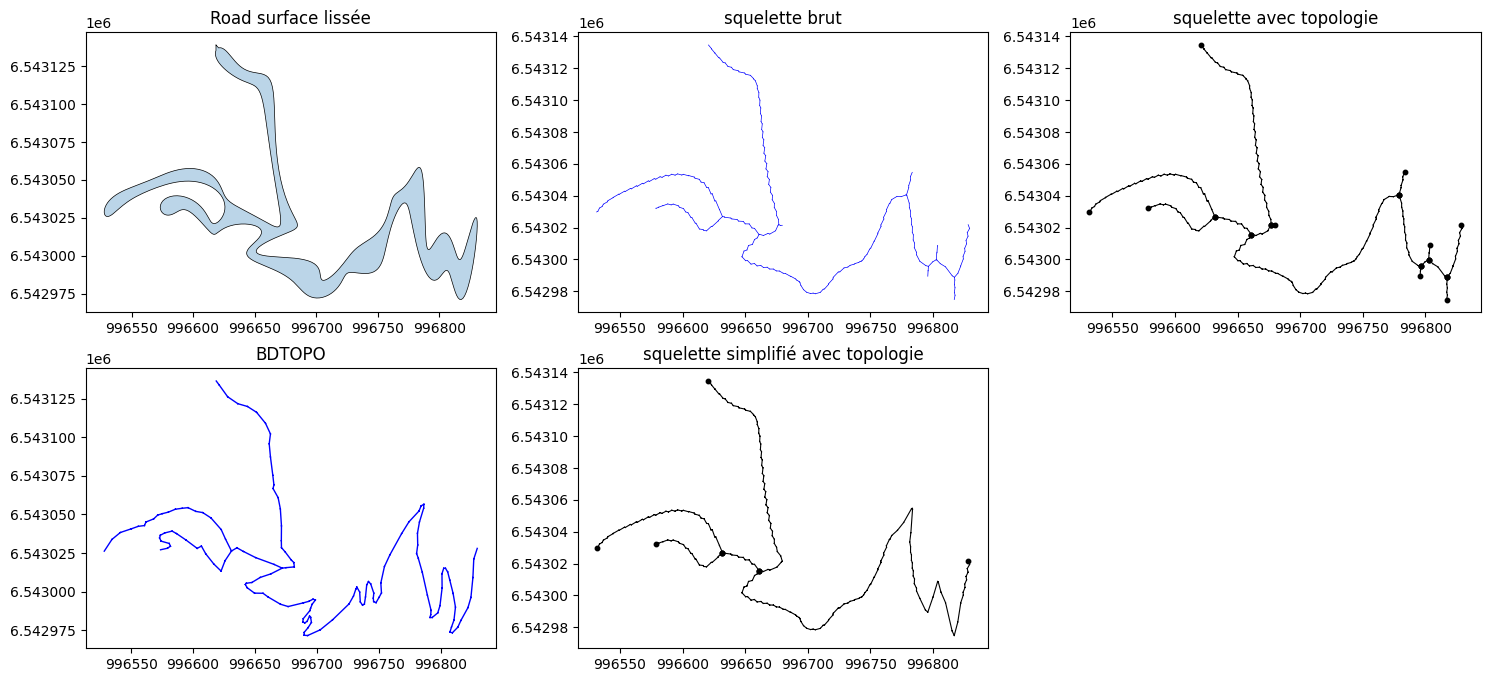

In [11]:
from footprint2graph.util.PlotRes import plotSqueletteTopo, matPlotShapefile

plt.figure(figsize=(18, 8))

ax1 = plt.subplot2grid((2, 3), (0, 0))
matPlotShapefile(RESPATH, 'image/road_surface_lissee_1.shp', ax1)
ax1.set_title('Road surface lissée')

ax2 = plt.subplot2grid((2, 3), (0, 1))
matPlotShapefile(RESPATH + 'network/', 'squelette_1.shp', ax2)
ax2.set_title('squelette brut')

ax3 = plt.subplot2grid((2, 3), (0, 2))
plotSqueletteTopo(RESPATH, ax3)
ax3.set_title('squelette avec topologie')

ax4 = plt.subplot2grid((2, 3), (1, 0))
network.plot(edges='b-', size=1.0, append=ax4)
ax4.set_title('BDTOPO')

ax5 = plt.subplot2grid((2, 3), (1, 1))
squelette.plot('k-', nodes='ko', size=0.8, append=ax5)
ax5.set_title('squelette simplifié avec topologie')

print ('')

In [12]:
report_file(RESPATH, 'topology1.json')

                  PIPELINE REPORT INFORMATION                    

Topologie
    Itération n° : 1
    Fin du traitement : 04/07/2026 23:24:16

--------------------------------------------------
Number of edges in the skeleton :      279
Number of skeleton edges removed for being too short :  0



## Step 4 : Construction des géométries agrégées pour chaque arc du squelette

1. Attribue les points des traces brutes à chaque arc de la topologie
	- Recalage avec l’algorithme de Newson and Krumm (2009)
2. Reconstruit les bons morceaux de traces candidats pour chaque arc de la topologie
3. Agrégation des morceaux de traces
4. Conflation des traces fusionnées afin d’obtenir un réseau de mobilité   

In [13]:
from footprint2graph import createNetworkGeom

SEARCH = 25
BUFFER = 20
createNetworkGeom(RESPATH, SEARCH, BUFFER, pipeline_idx)

Starting map-matching, aggregation, and conflation of GNSS trajectories.
Stage 4 completed: map-matching, aggregation, and conflation.


In [14]:
report_file(RESPATH, 'mapmatch1.json')

                  PIPELINE REPORT INFORMATION                    

Map Matching 
    Itération n° : 1
    Fin du traitement : 04/07/2026 23:24:31

Search radius (m):                25

Results
--------------------------------------------------
Map-matched points:               49111 ( 89.82 % )
Off-track points:                 5564 ( 10.18 % )

Quality
--------------------------------------------------
Root Mean Square Error (RMSE) :   3 m
Maximal displacement :            8.58 m



In [15]:
report_file(RESPATH, 'candidate1.json')

                  PIPELINE REPORT INFORMATION                    

Préparation des traces pour la fusion: segments candidats
    Itération n° : 1
    Fin du traitement : 04/07/2026 23:24:34

Results
--------------------------------------------------
Number of processed edges :                         5
Minimum number of candidate traces per edge :       189
Maximum number of candidate traces per edge :       571
Average number of candidate tracks per edge  :      305



In [16]:
report_file(RESPATH, 'aggregate1.json')

                  PIPELINE REPORT INFORMATION                    

Aggrégation des segments de traces candidats
    Itération n° : 1
    Fin du traitement : 04/07/2026 23:24:43

Results
--------------------------------------------------
Number of aggregations :                            5
Number of aggregations with 30 traces :             5
Number of aggregations with fewer than 30 traces :  0
Minimum number of traces in aggregation :           189
Average number of traces in aggregation :           304



In [17]:
report_file(RESPATH, 'conflate1.json')

                  PIPELINE REPORT INFORMATION                    

Conflation de la géométrie du réseau sur le squelette
    Itération n° : 1
    Fin du traitement : 04/07/2026 23:24:43

Results
--------------------------------------------------
Segments conflated :             5 ( 100.0 % )

Distorsion
--------------------------------------------------
Total distorsion RMSE :          2.906 m
Maximum distorsion RMSE :        17.18 %



### Visualisation du recalage sur le réseau

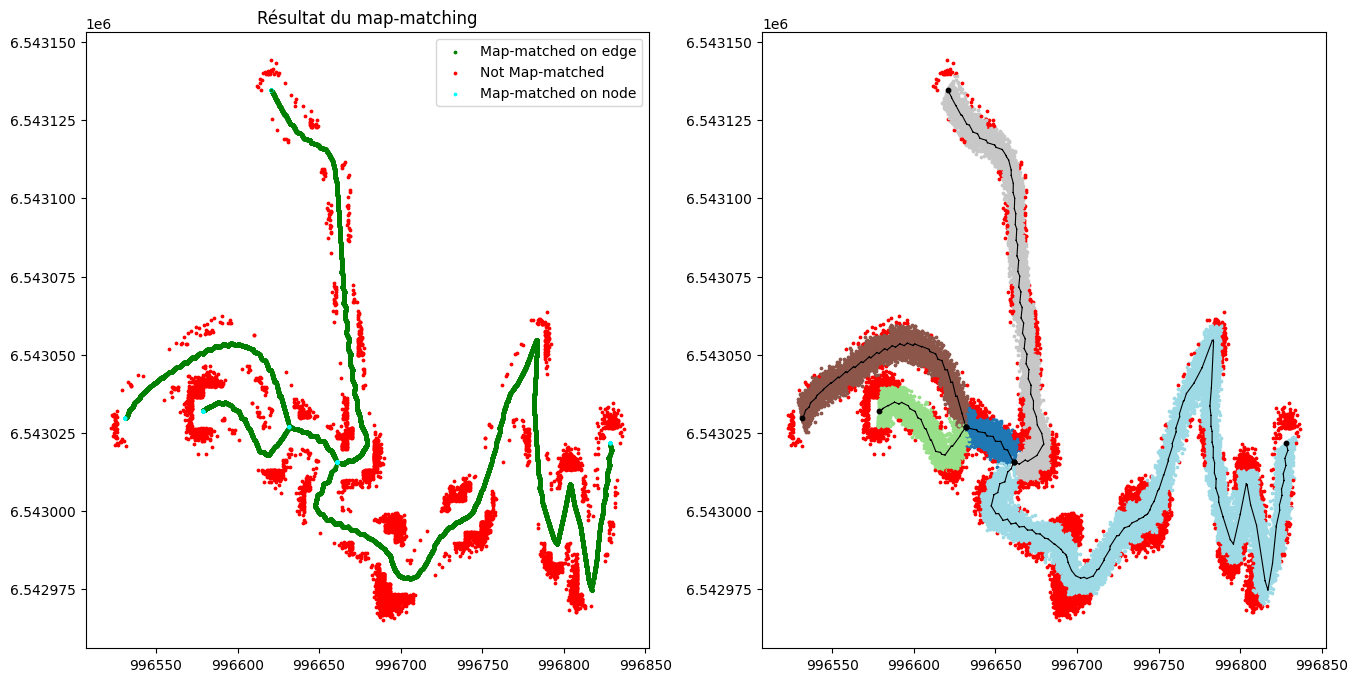

In [18]:
from footprint2graph.util.PlotRes import plotMM

plotMM(RESPATH, squelette)
plt.show()

### Visualisation des candidats pour l'agrégation

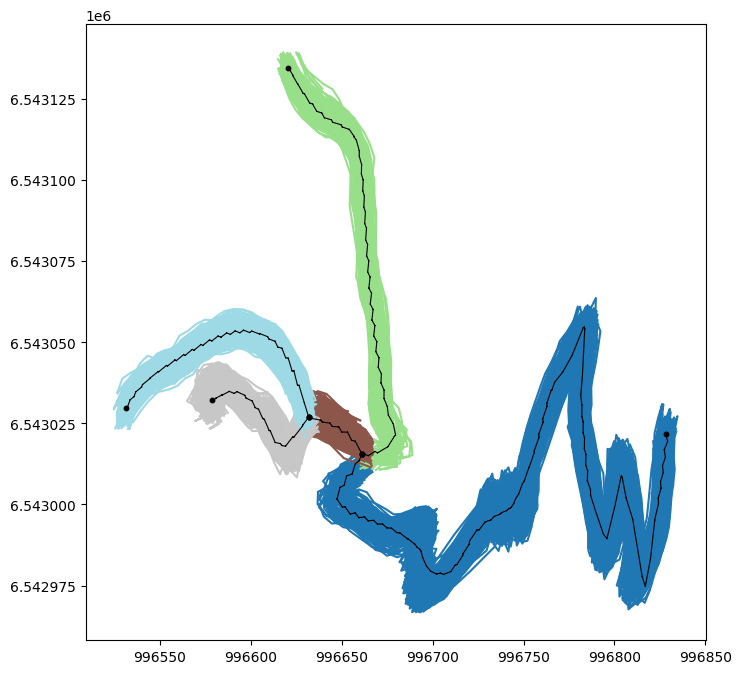

In [19]:
from footprint2graph.util.PlotRes import plotSegmentsConstruction

plt.figure(figsize=(8, 8))

ax1 = plt.subplot2grid((1, 1), (0, 0))
plotSegmentsConstruction(RESPATH, ax1, squelette)

### Visualisation de l'agrégation et de la conflation

Text(0.5, 1.0, 'CONFLATION')

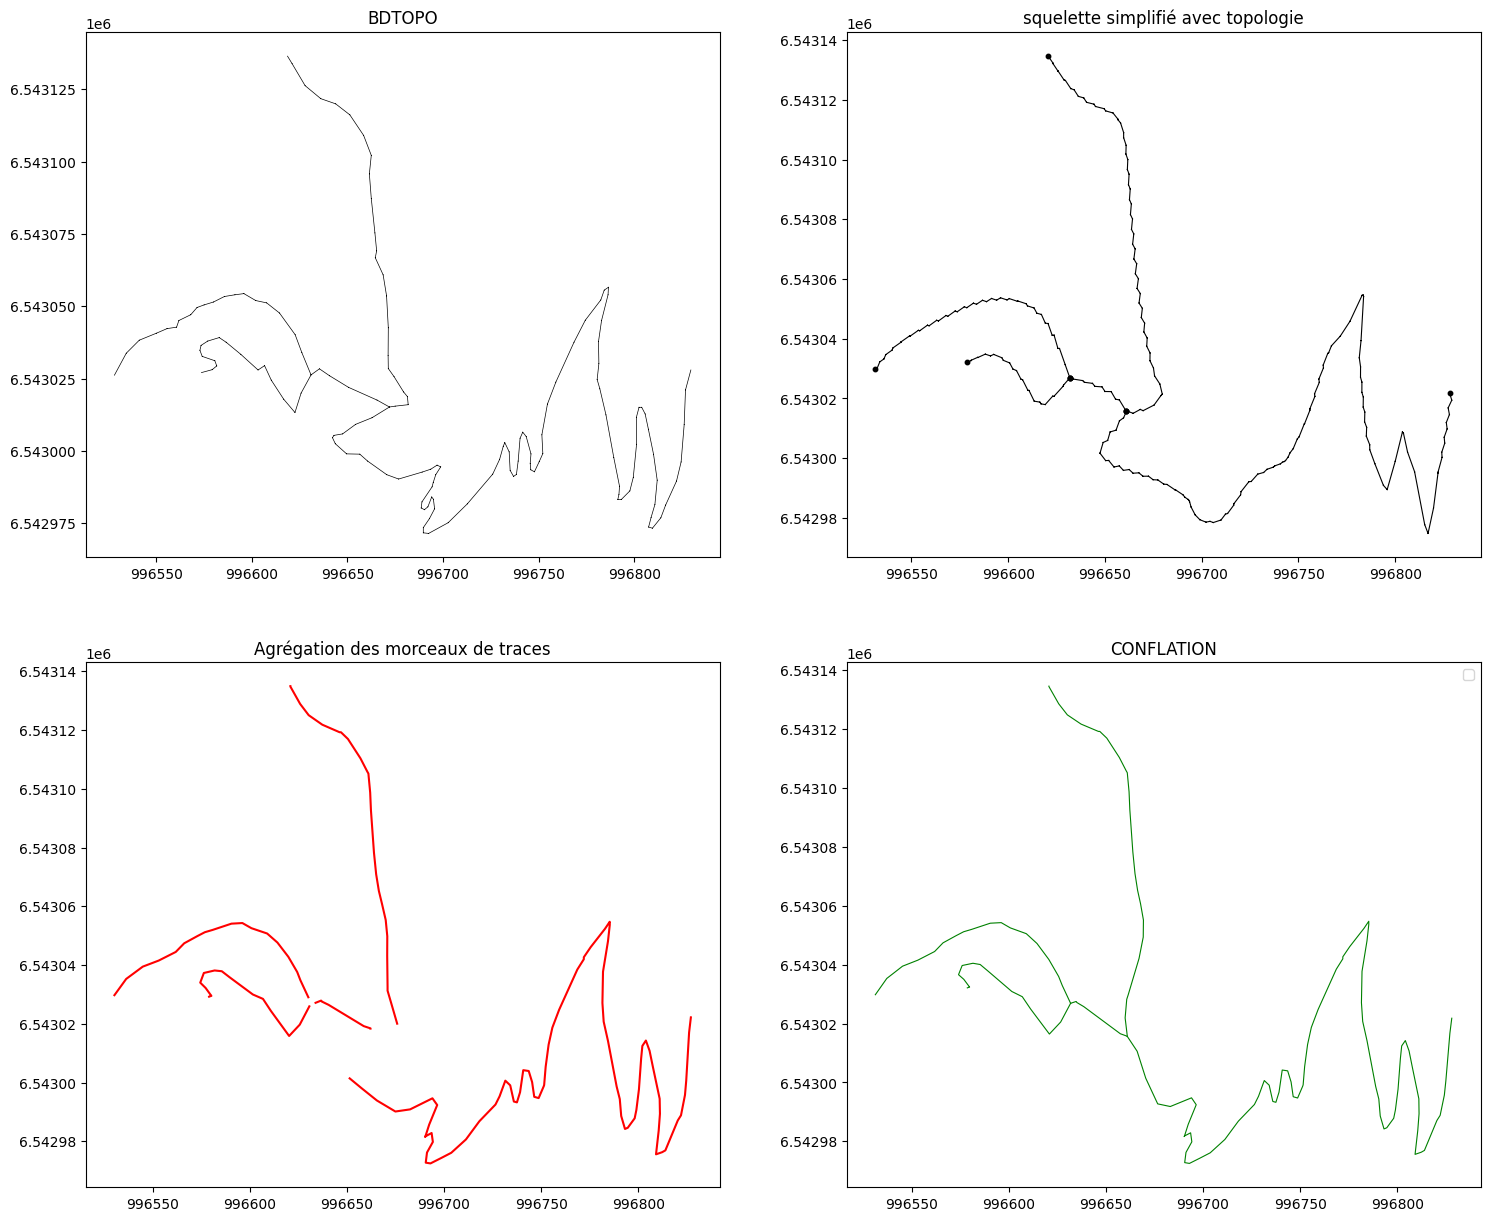

In [20]:
from footprint2graph.util.PlotRes import plotAggregation, plotConflation
import os

plt.figure(figsize=(18, 15))

# ---------------------------------------------------
ax1 = plt.subplot2grid((2, 2), (0, 0))
network.plot('k-', '', 'g-', 'r-', 0.5, ax1)
ax1.set_title('BDTOPO')

# ---------------------------------------------------
ax2 = plt.subplot2grid((2, 2), (0, 1))
squelette.plot('k-', nodes='ko', size=0.8, append=ax2)
ax2.set_title('squelette simplifié avec topologie')

# ---------------------------------------------------
ax3 = plt.subplot2grid((2, 2), (1, 0))
plotAggregation(RESPATH, ax3)
ax3.set_title('Agrégation des morceaux de traces')

# ---------------------------------------------------
ax4 = plt.subplot2grid((2, 2), (1, 1))
plotConflation(RESPATH, ax4)
ax4.set_title('CONFLATION')


## Regards sur le pipeline de construction

Warning 1: /home/md_vandamme/7_LIB/footprint2graph/test/resultjn/image/road_surface_lissee_1.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.


Text(0.5, 1.0, 'Réseau de mobilité')

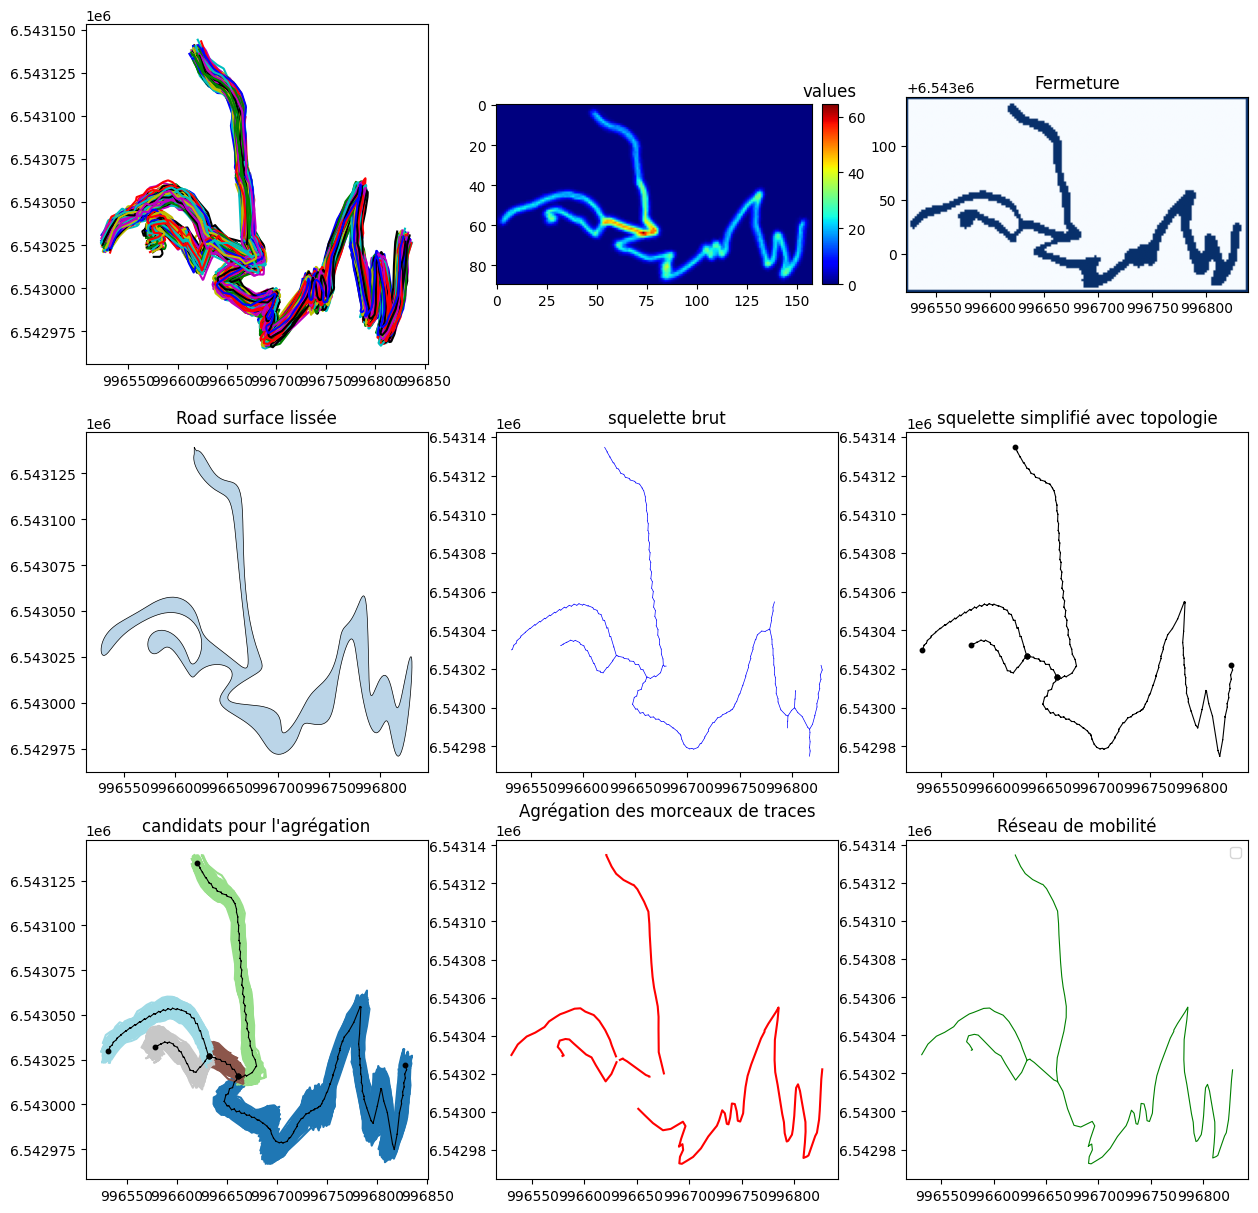

In [21]:
plt.figure(figsize=(15, 15))

# ---------------------------------------------------
ax1 = plt.subplot2grid((3, 3), (0, 0))
collection.plot(append=ax1)

ax2 = plt.subplot2grid((3, 3), (0, 1))
rasterG1 = tkl.RasterReader.readFromAscFile(RESPATH + 'image/G1_1.asc', af_name='G1', separator='\t')
mapDensity = rasterG1.getAFMap('G1')
mapDensity.plot(append=ax2, cmap='jet', vmin=0)

ax3 = plt.subplot2grid((3, 3), (0, 2))
maPlotRasterTiff(RESPATH, 'image/erosion_1.tif', ax3)
ax3.set_title('Fermeture')

# ---------------------------------------------------
ax4 = plt.subplot2grid((3, 3), (1, 0))
matPlotShapefile(RESPATH, 'image/road_surface_lissee_1.shp', ax4)
ax4.set_title('Road surface lissée')

ax5 = plt.subplot2grid((3, 3), (1, 1))
matPlotShapefile(RESPATH + 'network/', 'squelette_1.shp', ax5)
ax5.set_title('squelette brut')

ax6 = plt.subplot2grid((3, 3), (1, 2))
squelette.plot('k-', nodes='ko', size=0.8, append=ax5)
ax6.set_title('squelette simplifié avec topologie')

# ---------------------------------------------------
ax7 = plt.subplot2grid((3, 3), (2, 0))
plotSegmentsConstruction(RESPATH, ax7, squelette)
ax7.set_title("candidats pour l'agrégation")

ax8 = plt.subplot2grid((3, 3), (2, 1))
plotAggregation(RESPATH, ax8)
ax8.set_title('Agrégation des morceaux de traces')

ax9 = plt.subplot2grid((3, 3), (2, 2))
plotConflation(RESPATH, ax9)
ax9.set_title('Réseau de mobilité')